# Chi-square test (CJ - Sam)

In [3]:
# Sales Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset = pd.read_csv('SuperStore_Orders.csv', encoding='ISO-8859-1', sep=',')
dataset

df = pd.DataFrame(dataset)
df

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01-01-2011,06-01-2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.1400,35.46,Medium,2011
1,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.0360,9.72,Medium,2011
2,HU-2011-1220,01-01-2011,05-01-2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.6400,8.17,High,2011
3,IT-2011-3647632,01-01-2011,05-01-2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.0550,4.82,High,2011
4,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.7700,4.70,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,31-12-2014,04-01-2015,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31-12-2014,05-01-2015,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31-12-2014,02-01-2015,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31-12-2014,06-01-2015,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014


In [4]:
from scipy.stats import chi2_contingency
# Misal dataset sudah ada di df
contingency_table = pd.crosstab(df['ship_mode'], df['order_priority'])
print(contingency_table)



order_priority  Critical  High   Low  Medium
ship_mode                                   
First Class         1734  3413     0    2358
Same Day             742  1269     0     690
Second Class        1456  4010     0    4843
Standard Class         0  6809  2424   21542


In [8]:
import pandas as pd
from scipy.stats import chi2_contingency

# --- 1. Load data ---
# Misalnya data kamu ada di CSV bernama "superstore.csv"
# df = pd.read_csv("SuperStore_Orders.csv")

# --- 2. Buat contingency table ---
contingency_table = pd.crosstab(df['ship_mode'], df['order_priority'])
print("Contingency Table:\n", contingency_table, "\n")

# --- 3. Hitung Chi-Square ---
chi2, p, dof, expected = chi2_contingency(contingency_table)

# --- 4. Hasil ---
print("Chi-square Statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)
print("\nExpected Frequencies:\n", expected)

# --- 5. Interpretasi ---
alpha = 0.05
if p < alpha:
    print("\n✅ Tolak H0: Ada hubungan signifikan antara ship_mode dan order_priority")
else:
    print("\n❌ Gagal menolak H0: Tidak ada hubungan signifikan antara ship_mode dan order_priority")


Contingency Table:
 order_priority  Critical  High   Low  Medium
ship_mode                                   
First Class         1734  3413     0    2358
Same Day             742  1269     0     690
Second Class        1456  4010     0    4843
Standard Class         0  6809  2424   21542 

Chi-square Statistic: 12411.07931567507
Degrees of freedom: 9
p-value: 0.0

Expected Frequencies:
 [[  575.34919088  2268.18102944   354.69136284  4306.77841685]
 [  207.06437902   816.30339247   127.65108208  1549.98114642]
 [  790.30976799  3115.61335543   487.2102944   5915.86658218]
 [ 2359.27666212  9300.90222266  1454.44726067 17660.37385455]]

✅ Tolak H0: Ada hubungan signifikan antara ship_mode dan order_priority


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, chi2

# --- Fungsi Chi-Square dengan Critical Value ---
def chi_square_test(df, col1, col2, alpha=0.05):
    print(f"\n=== Chi-Square Test: {col1} vs {col2} ===")

    # 1. Buat contingency table
    contingency_table = pd.crosstab(df[col1], df[col2])
    print("\nContingency Table:\n", contingency_table)

    # 2. Chi-Square Test
    chi2_stat, p, dof, expected = chi2_contingency(contingency_table)

    # 3. Critical value
    critical = chi2.ppf(1 - alpha, dof)

    print("\nChi-square Statistic:", chi2_stat)
    print("Degrees of freedom:", dof)
    print("p-value:", p)
    print(f"Critical value (α={alpha}):", critical)

    # 4. Interpretasi
    if chi2_stat > critical:
        print(f"✅ Tolak H0 (karena {chi2_stat:.2f} > {critical:.2f})")
    else:
        print(f"❌ Menerima H0 (karena {chi2_stat:.2f} <= {critical:.2f})")

    # 5. Expected values
    expected_df = pd.DataFrame(expected, 
                               index=contingency_table.index, 
                               columns=contingency_table.columns)
    print("\nExpected Values (Jika Independen):\n", expected_df.round(2))

    return chi2_stat, dof, p, critical


    # # 4. Visualisasi
    # plt.figure(figsize=(8, 6))
    # sns.heatmap(contingency_table, annot=True, fmt="d", cmap="Blues", cbar=False)
    # plt.title(f"Distribusi {col1} vs {col2}")
    # plt.ylabel(col1)
    # plt.xlabel(col2)
    # plt.show()

    # # --- Heatmap Ekspektasi ---
    # # --- Heatmap Expected Values (Ekspektasi) ---
    # expected_df = pd.DataFrame(expected, 
    #                         index=contingency_table.index, 
    #                         columns=contingency_table.columns)

    # plt.figure(figsize=(10, 6))
    # sns.heatmap(expected_df.round(0),   # Bulatkan ke integer agar mudah dibaca
    #             annot=True,             # Tampilkan angka di tiap sel
    #             fmt="g",                # Format umum integer
    #             cmap="Oranges",         # Warna heatmap
    #             cbar=False)             # Hilangkan colorbar
    # plt.title(f"Ekspektasi (Jika {col1} & {col2} Independen)")
    # plt.ylabel(col1)
    # plt.xlabel(col2)
    # plt.show()   


### Sample

In [49]:
# 1. Ship Mode vs Order Priority
chi_square_test(df, 'ship_mode', 'order_priority')

# 2. Segment vs Order Priority
chi_square_test(df, 'segment', 'order_priority')

# 3. Region vs Ship Mode
chi_square_test(df, 'region', 'ship_mode')

# 4. Category vs Order Priority
chi_square_test(df, 'category', 'order_priority')

# 5. Segment vs Ship Mode
chi_square_test(df, 'region', 'ship_mode')



=== Chi-Square Test: ship_mode vs order_priority ===

Contingency Table:
 order_priority  Critical  High   Low  Medium
ship_mode                                   
First Class         1734  3413     0    2358
Same Day             742  1269     0     690
Second Class        1456  4010     0    4843
Standard Class         0  6809  2424   21542

Chi-square Statistic: 12411.07931567507
Degrees of freedom: 9
p-value: 0.0
✅ Tolak H0: Ada hubungan signifikan antara ship_mode dan order_priority

Expected Values (Jika Independen):
 order_priority  Critical     High      Low    Medium
ship_mode                                           
First Class       575.35  2268.18   354.69   4306.78
Same Day          207.06   816.30   127.65   1549.98
Second Class      790.31  3115.61   487.21   5915.87
Standard Class   2359.28  9300.90  1454.45  17660.37

=== Chi-Square Test: segment vs order_priority ===

Contingency Table:
 order_priority  Critical  High   Low  Medium
segment                           

### Focus on Ship Mode

In [5]:
# 1. Ship Mode vs Order Priority
chi_square_test(df, 'ship_mode', 'order_priority')

# 2. Segment vs Order Priority
chi_square_test(df, 'ship_mode','segment')

# 3. Region vs Ship Mode
chi_square_test(df, 'ship_mode','region')

# 4. Category vs Order Priority
chi_square_test(df, 'ship_mode', 'category')



=== Chi-Square Test: ship_mode vs order_priority ===

Contingency Table:
 order_priority  Critical  High   Low  Medium
ship_mode                                   
First Class         1734  3413     0    2358
Same Day             742  1269     0     690
Second Class        1456  4010     0    4843
Standard Class         0  6809  2424   21542

Chi-square Statistic: 12411.07931567507
Degrees of freedom: 9
p-value: 0.0
Critical value (α=0.05): 16.918977604620448
✅ Tolak H0 (karena 12411.08 > 16.92)

Expected Values (Jika Independen):
 order_priority  Critical     High      Low    Medium
ship_mode                                           
First Class       575.35  2268.18   354.69   4306.78
Same Day          207.06   816.30   127.65   1549.98
Second Class      790.31  3115.61   487.21   5915.87
Standard Class   2359.28  9300.90  1454.45  17660.37

=== Chi-Square Test: ship_mode vs segment ===

Contingency Table:
 segment         Consumer  Corporate  Home Office
ship_mode                 

(np.float64(2.5977282981411434),
 6,
 np.float64(0.8573739834400929),
 np.float64(12.591587243743977))

### Visualization

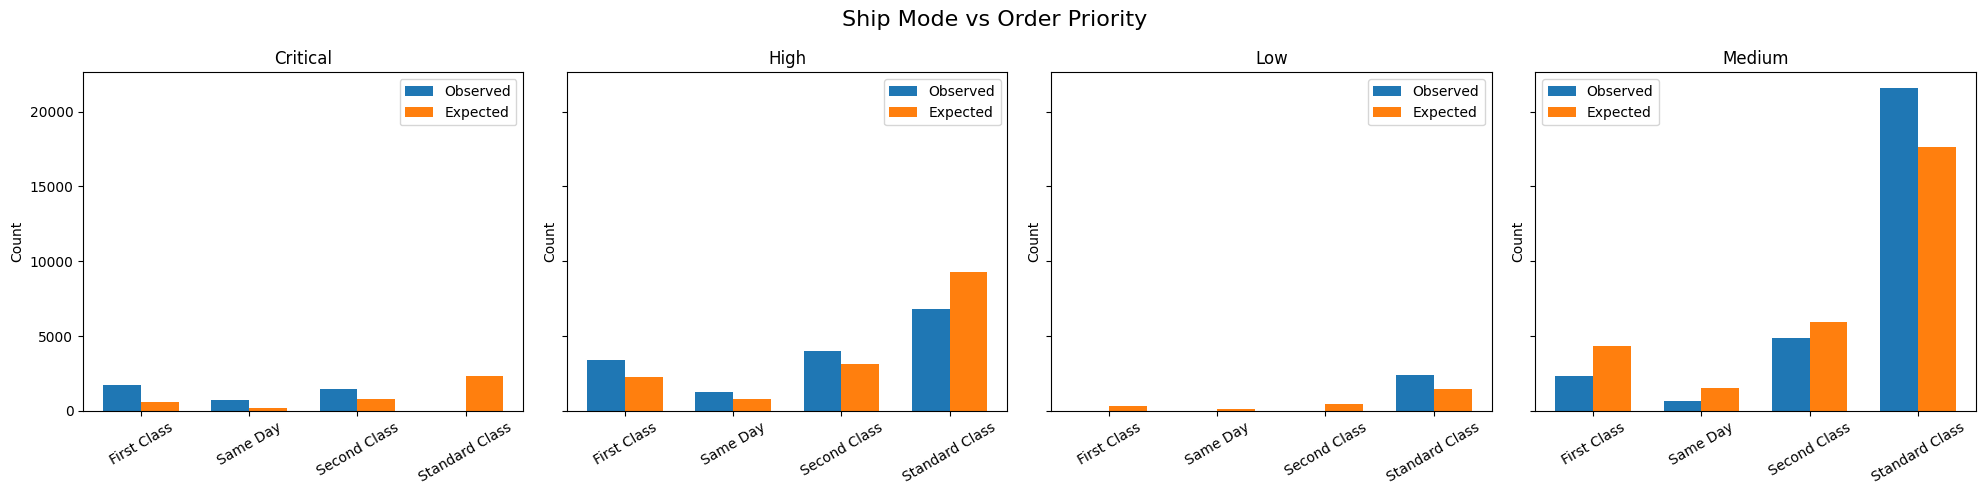

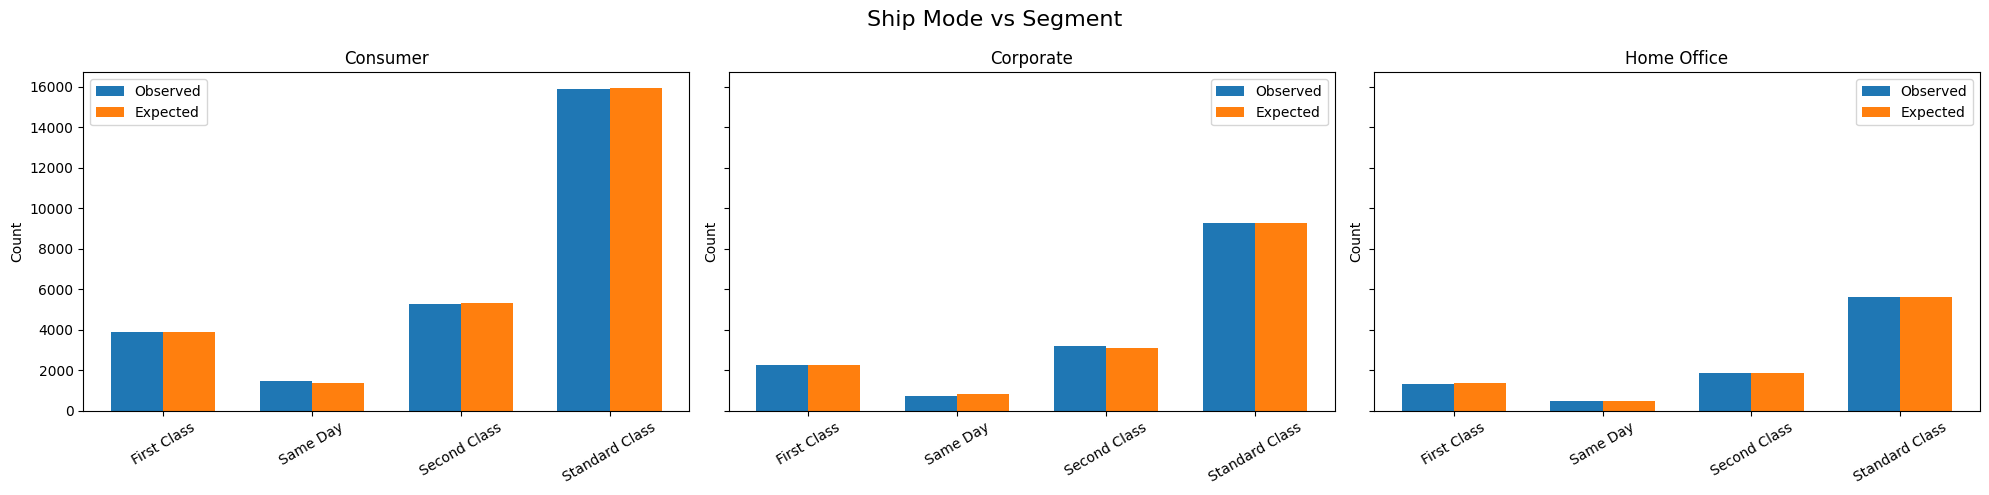

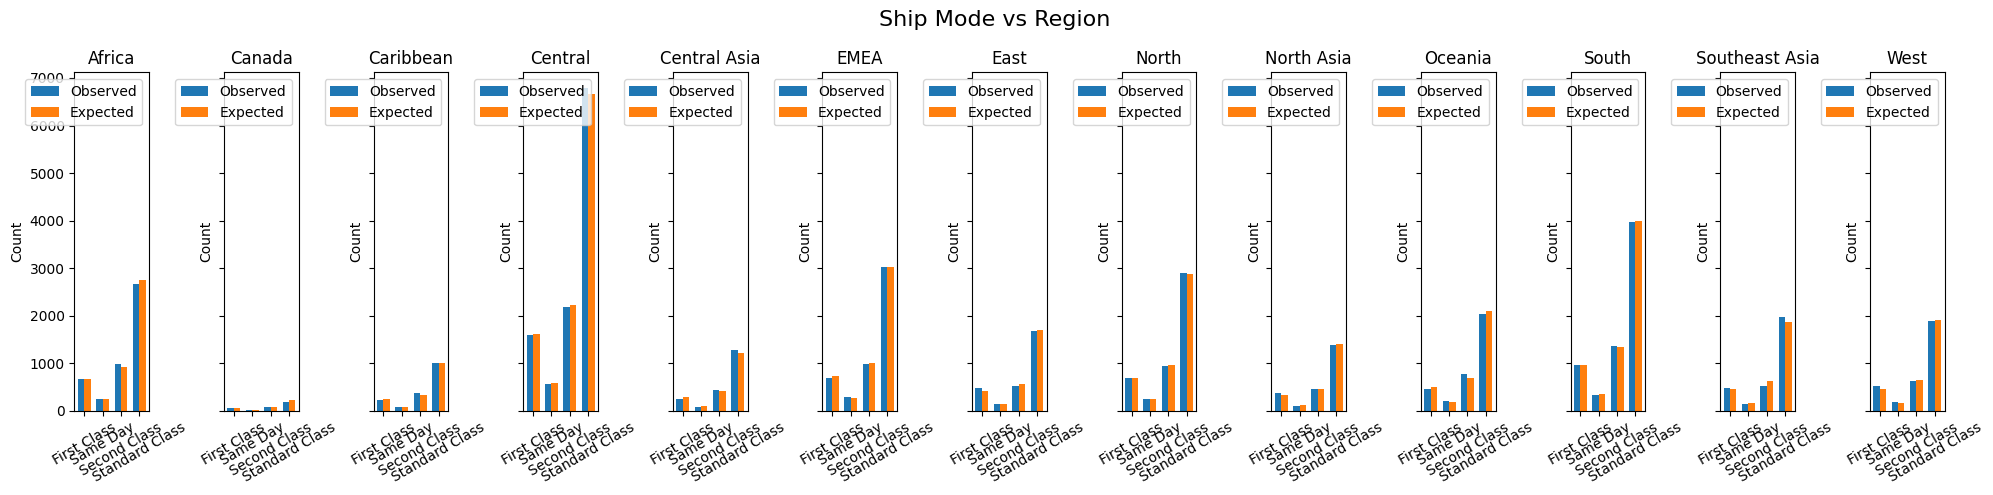

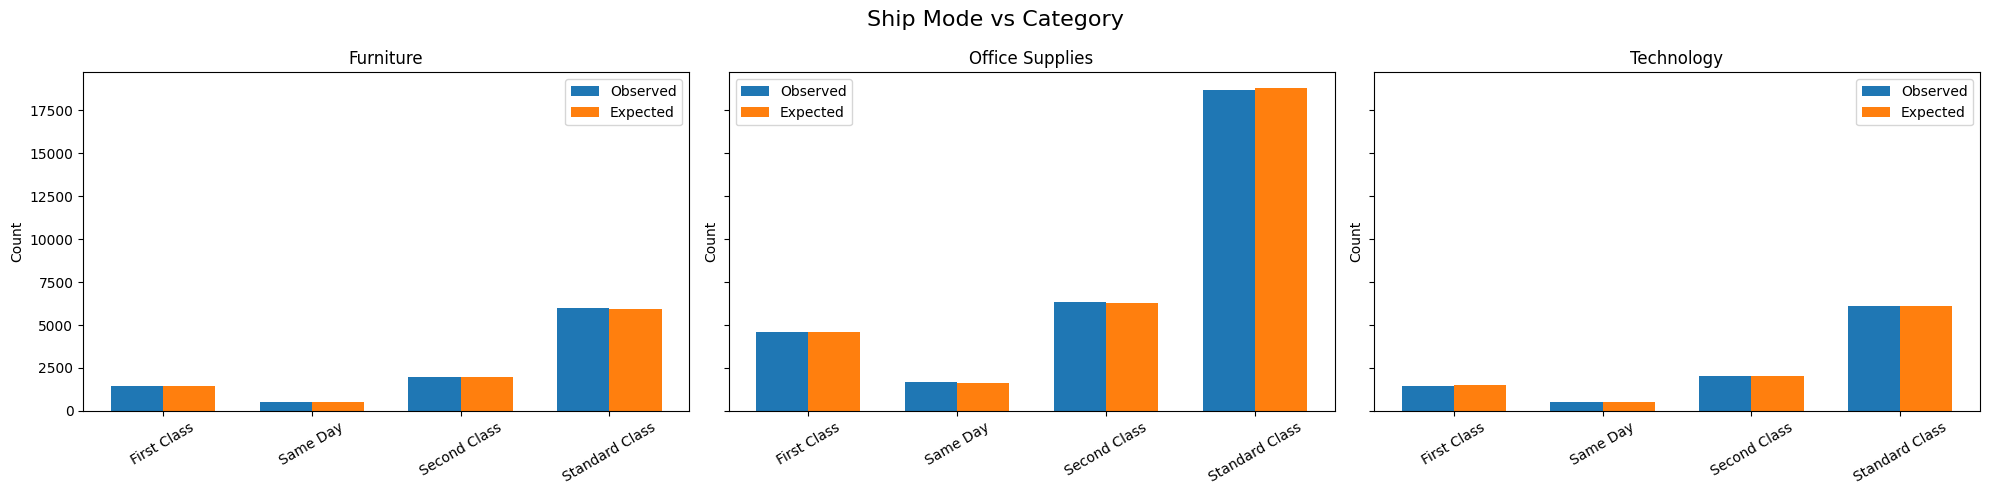

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# =============== 1. Ship Mode vs Order Priority ===============
observed_1 = pd.DataFrame({
    "Critical": [1734, 742, 1456, 0],
    "High": [3413, 1269, 4010, 6809],
    "Low": [0, 0, 0, 2424],
    "Medium": [2358, 690, 4843, 21542]
}, index=["First Class", "Same Day", "Second Class", "Standard Class"])

expected_1 = pd.DataFrame({
    "Critical": [575.35, 207.06, 790.31, 2359.28],
    "High": [2268.18, 816.30, 3115.61, 9300.90],
    "Low": [354.69, 127.65, 487.21, 1454.45],
    "Medium": [4306.78, 1549.98, 5915.87, 17660.37]
}, index=observed_1.index)


# =============== 2. Ship Mode vs Segment ===============
observed_2 = pd.DataFrame({
    "Consumer": [3918, 1467, 5257, 15876],
    "Corporate": [2245, 728, 3198, 9258],
    "Home Office": [1342, 506, 1854, 5641]
}, index=["First Class", "Same Day", "Second Class", "Standard Class"])

expected_2 = pd.DataFrame({
    "Consumer": [3880.24, 1396.47, 5329.97, 15911.32],
    "Corporate": [2257.65, 812.51, 3101.14, 9257.70],
    "Home Office": [1367.11, 492.01, 1877.89, 5605.98]
}, index=observed_2.index)


# =============== 3. Ship Mode vs Region ===============
observed_3 = pd.DataFrame({
    "Africa": [679, 257, 992, 2659],
    "Canada": [70, 29, 91, 194],
    "Caribbean": [231, 85, 372, 1002],
    "Central": [1593, 568, 2176, 6780],
    "Central Asia": [252, 79, 440, 1277],
    "EMEA": [700, 300, 993, 3036],
    "East": [490, 155, 530, 1673],
    "North": [684, 246, 954, 2901],
    "North Asia": [385, 106, 470, 1377],
    "Oceania": [455, 205, 779, 2048],
    "South": [958, 341, 1368, 3978],
    "Southeast Asia": [493, 145, 523, 1968],
    "West": [515, 185, 621, 1882]
}, index=["First Class", "Same Day", "Second Class", "Standard Class"])

expected_3 = pd.DataFrame({
    "Africa": [671.19, 241.56, 921.96, 2752.29],
    "Canada": [56.19, 20.22, 77.18, 230.41],
    "Caribbean": [247.29, 89.00, 339.68, 1014.03],
    "Central": [1626.69, 585.44, 2234.45, 6670.42],
    "Central Asia": [299.67, 107.85, 411.64, 1228.84],
    "EMEA": [735.87, 264.83, 1010.80, 3017.50],
    "East": [416.73, 149.98, 572.43, 1708.86],
    "North": [700.16, 251.98, 961.76, 2871.09],
    "North Asia": [342.11, 123.12, 469.92, 1402.85],
    "Oceania": [510.23, 183.63, 700.87, 2092.27],
    "South": [972.33, 349.93, 1335.61, 3987.13],
    "Southeast Asia": [457.85, 164.78, 628.91, 1877.46],
    "West": [468.68, 168.67, 643.78, 1921.86]
}, index=observed_3.index)


# =============== 4. Ship Mode vs Category ===============
observed_4 = pd.DataFrame({
    "Furniture": [1431, 508, 1968, 5969],
    "Office Supplies": [4598, 1675, 6311, 18689],
    "Technology": [1476, 518, 2030, 6117]
}, index=["First Class", "Same Day", "Second Class", "Standard Class"])

expected_4 = pd.DataFrame({
    "Furniture": [1445.10, 520.08, 1985.02, 5925.79],
    "Office Supplies": [4576.02, 1646.88, 6285.70, 18764.41],
    "Technology": [1483.88, 534.04, 2038.28, 6084.80]
}, index=observed_4.index)


# =============== Function for Plotting ===============
def plot_barchart(observed, expected, title, x_label):
    fig, axes = plt.subplots(1, observed.shape[1], figsize=(20, 5), sharey=True)
    if observed.shape[1] == 1:  # kalau cuma 1 kolom
        axes = [axes]
    for i, col in enumerate(observed.columns):
        ax = axes[i]
        x = range(len(observed.index))
        width = 0.35
        ax.bar([pos - width/2 for pos in x], observed[col], width, label="Observed")
        ax.bar([pos + width/2 for pos in x], expected[col], width, label="Expected")
        ax.set_title(f"{col}")
        ax.set_xticks(range(len(observed.index)))
        ax.set_xticklabels(observed.index, rotation=30)
        ax.set_ylabel("Count")
        ax.legend()
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


# =============== Generate All Charts ===============
plot_barchart(observed_1, expected_1, "Ship Mode vs Order Priority", "Ship Mode")
plot_barchart(observed_2, expected_2, "Ship Mode vs Segment", "Ship Mode")
plot_barchart(observed_3, expected_3, "Ship Mode vs Region", "Ship Mode")
plot_barchart(observed_4, expected_4, "Ship Mode vs Category", "Ship Mode")
